# Smart HVAC Energy Analytics & Predictive Maintenance System

## Phase 3 — Exploratory Data Analysis

This notebook explores the preprocessed LBNL RTU dataset to understand its structure, data quality, class distribution, and important operating characteristics before feature engineering and model development.

The analysis focuses on identifying patterns that are relevant to HVAC fault detection.

## 1. Import Libraries

The required Python libraries are imported for:

- Data manipulation and analysis using Pandas and NumPy
- Data visualization using Matplotlib and Seaborn
- Suppressing non-critical warnings during exploratory analysis

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

## 2. Load Processed Datasets

The processed LBNL RTU datasets generated during the preprocessing phase are loaded for exploratory analysis.

The simulation dataset is the primary dataset used for fault detection analysis, while the site dataset is retained for reference and further analysis where required.

In [4]:
processed_simulation = pd.read_csv(
    "../outputs/processed_simulation.csv"
)

processed_site = pd.read_csv(
    "../outputs/processed_site.csv"
)

## 3. Dataset Overview

The simulation dataset is inspected to understand its size, structure, and feature types.

This provides an initial view of the sensor measurements and target-related columns that will be used in later stages of fault detection.

In [5]:
print("=" * 60)
print("SIMULATION DATASET OVERVIEW")
print("=" * 60)

print(f"Rows    : {processed_simulation.shape[0]:,}")
print(f"Columns : {processed_simulation.shape[1]}")

display(processed_simulation.head())

print("\nData Types:")
display(processed_simulation.dtypes)

SIMULATION DATASET OVERVIEW
Rows    : 1,871,233
Columns : 24


,RTU_COMP_WATT,RTU_OA_FLOW,RTU_OA_HUM,RTU_OA_TEMP,RTU_RA_FLOW,RTU_RA_HUM,RTU_RA_TEMP,RTU_REFG_COND_PRES,RTU_REFG_COND_TEMP,RTU_REFG_DISC_PRES,...,RTU_SA_FLOW,RTU_SA_HUM,RTU_SA_TEMP,RTU_SEN_CAPA,RTU_STG_STA,RTU_TOT_CAPA,RTU_TOT_WATT,ZA_HUM,ZA_TEMP,health_status
0,2097.6797,181.93083,49.361565,55.040030,2941.1106,50.000000,75.200000,24763394.0,79.043396,25093532.0,...,2941.1106,98.70536,52.272797,14631.9375,1.0,17422.904,2192.1084,59.926773,73.611046,Healthy
1,2089.0981,181.93083,59.133976,55.033990,2941.1106,59.898830,73.353580,24861452.0,79.312790,25198948.0,...,2941.1106,100.00000,53.288155,12823.3100,1.0,17655.139,2183.5269,59.898830,73.353580,Healthy
2,2089.8665,181.93083,59.105840,55.028000,2941.1106,59.870330,73.096176,24846182.0,79.270930,25183480.0,...,2941.1106,100.00000,53.024975,12819.8160,1.0,17625.334,2184.2952,59.870330,73.096176,Healthy
3,2091.4324,181.93083,59.077980,55.022015,2941.1106,59.842117,72.839096,24822794.0,79.206710,25158652.0,...,2941.1106,100.00000,52.775420,12811.6670,1.0,17576.230,2185.8610,59.842117,72.839096,Healthy
4,2093.2980,181.93083,59.050636,55.016030,2941.1106,59.814423,72.583115,24796212.0,79.133650,25130132.0,...,2941.1106,100.00000,52.532455,12801.4100,1.0,17519.484,2187.7268,59.814423,72.583115,Healthy



Data Types:


RTU_COMP_WATT         float64
RTU_OA_FLOW           float64
RTU_OA_HUM            float64
RTU_OA_TEMP           float64
RTU_RA_FLOW           float64
RTU_RA_HUM            float64
RTU_RA_TEMP           float64
RTU_REFG_COND_PRES    float64
RTU_REFG_COND_TEMP    float64
RTU_REFG_DISC_PRES    float64
RTU_REFG_DISC_TEMP    float64
RTU_REFG_SUCT_PRES    float64
RTU_REFG_SUCT_TEMP    float64
RTU_SA_FAN_WATT       float64
RTU_SA_FLOW           float64
RTU_SA_HUM            float64
RTU_SA_TEMP           float64
RTU_SEN_CAPA          float64
RTU_STG_STA           float64
RTU_TOT_CAPA          float64
RTU_TOT_WATT          float64
ZA_HUM                float64
ZA_TEMP               float64
health_status             str
dtype: object

## 4. Statistical Summary

Descriptive statistics are used to understand the numerical characteristics of the HVAC sensor measurements.

The summary includes:

- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

This helps identify the typical operating ranges and potential variations in the sensor data.

In [6]:
processed_simulation.describe().T

,count,mean,std,min,25%,50%,75%,max
RTU_COMP_WATT,1871233.0,1.470985e+03,9.568278e+02,0.000000e+00,8.573445e+02,1.493482e+03,2.285219e+03,3.883472e+03
RTU_OA_FLOW,1871233.0,1.735340e+02,1.690984e+01,1.273516e+02,1.819308e+02,1.819308e+02,1.819308e+02,1.819308e+02
RTU_OA_HUM,1871233.0,4.542965e+01,6.619212e+00,3.071821e+01,3.950308e+01,4.598917e+01,5.097532e+01,8.188507e+01
RTU_OA_TEMP,1871233.0,6.126659e+01,5.852898e+00,4.882919e+01,5.701999e+01,6.008001e+01,6.494003e+01,8.671422e+01
RTU_RA_FLOW,1871233.0,2.198021e+03,6.018000e+02,1.029389e+03,1.647022e+03,2.058777e+03,2.941111e+03,2.941111e+03
RTU_RA_HUM,1871233.0,4.601796e+01,6.704756e+00,3.111653e+01,4.001482e+01,4.658479e+01,5.163526e+01,8.294585e+01
RTU_RA_TEMP,1871233.0,7.581843e+01,4.484512e+00,6.691692e+01,7.168080e+01,7.509262e+01,7.990484e+01,8.405224e+01
RTU_REFG_COND_PRES,1871233.0,2.438016e+07,3.562914e+06,1.604767e+07,2.195325e+07,2.461224e+07,2.673113e+07,3.962312e+07
RTU_REFG_COND_TEMP,1871233.0,7.743687e+01,1.003126e+01,5.103121e+01,7.097075e+01,7.863551e+01,8.431094e+01,1.129917e+02
RTU_REFG_DISC_PRES,1871233.0,2.459826e+07,3.642419e+06,1.605459e+07,2.216071e+07,2.488570e+07,2.701242e+07,3.990300e+07


## 5. Health Status Distribution

The distribution of healthy and faulty operating conditions is examined to understand the class composition of the dataset.

This is important for evaluating whether the fault detection model will receive sufficiently representative examples of both operating conditions.

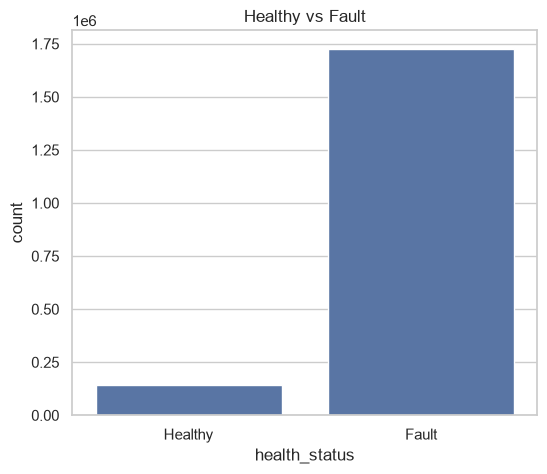

In [5]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=processed_simulation,
    x="health_status"
)

plt.title("Healthy vs Fault")
plt.show()

### Class Distribution

The percentage distribution provides a numerical view of the healthy and faulty samples and helps identify potential class imbalance before model training.

In [7]:
class_distribution = (
    processed_simulation["health_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(class_distribution)

health_status
Fault      92.31
Healthy     7.69
Name: proportion, dtype: float64

In [8]:
processed_simulation["health_status"].value_counts()

health_status
Fault      1727292
Healthy     143941
Name: count, dtype: int64

In [9]:
processed_simulation["health_status"].value_counts(normalize=True) * 100

health_status
Fault      92.307692
Healthy     7.692308
Name: proportion, dtype: float64

## 6. Data Quality Analysis

The processed simulation dataset is checked for missing values and duplicate records to verify its quality before feature engineering and model development.

In [8]:
missing = processed_simulation.isnull().sum()

missing = missing[missing > 0]

print(missing)

RTU_LA_COND_TEMP        1871233
RTU_MA_HUM              1871233
RTU_MA_TEMP             1871233
RTU_REFG_COND_TEMP_1    1871233
RTU_REFG_COND_TEMP_2    1871233
RTU_REFG_DISC_PRES_1    1871233
RTU_REFG_DISC_PRES_2    1871233
RTU_REFG_DISC_TEMP_1    1871233
RTU_REFG_DISC_TEMP_2    1871233
RTU_REFG_SUCT_PRES_1    1871233
RTU_REFG_SUCT_PRES_2    1871233
RTU_REFG_SUCT_TEMP_1    1871233
RTU_REFG_SUCT_TEMP_2    1871233
dtype: int64


## 9. Numerical Feature Correlation

Correlation analysis is used to examine relationships between numerical HVAC measurements.

Understanding these relationships helps identify potentially informative sensor variables and highly correlated features before feature engineering.

In [9]:
numeric_df = processed_simulation.select_dtypes(include=np.number)

corr = numeric_df.corr()

In [16]:
processed_simulation = processed_simulation.dropna(axis=1, how="all")

In [17]:
print(processed_simulation.shape)
processed_simulation.columns.tolist()

(1871233, 28)


['Datetime',
 'RTU_COMP_WATT',
 'RTU_OA_FLOW',
 'RTU_OA_HUM',
 'RTU_OA_TEMP',
 'RTU_RA_FLOW',
 'RTU_RA_HUM',
 'RTU_RA_TEMP',
 'RTU_REFG_COND_PRES',
 'RTU_REFG_COND_TEMP',
 'RTU_REFG_DISC_PRES',
 'RTU_REFG_DISC_TEMP',
 'RTU_REFG_SUCT_PRES',
 'RTU_REFG_SUCT_TEMP',
 'RTU_SA_FAN_WATT',
 'RTU_SA_FLOW',
 'RTU_SA_HUM',
 'RTU_SA_TEMP',
 'RTU_SEN_CAPA',
 'RTU_STG_STA',
 'RTU_TOT_CAPA',
 'RTU_TOT_WATT',
 'ZA_HUM',
 'ZA_TEMP',
 'ZA_TEMP_SPT',
 'health_status',
 'fault_type',
 'severity']

In [18]:
print("="*60)
print("SMART HVAC FAULT DETECTION DATASET")
print("="*60)

print(f"Rows: {processed_simulation.shape[0]:,}")
print(f"Columns: {processed_simulation.shape[1]}")

display(processed_simulation.head())

processed_simulation.info()

SMART HVAC FAULT DETECTION DATASET
Rows: 1,871,233
Columns: 28


,Datetime,RTU_COMP_WATT,RTU_OA_FLOW,RTU_OA_HUM,RTU_OA_TEMP,RTU_RA_FLOW,RTU_RA_HUM,RTU_RA_TEMP,RTU_REFG_COND_PRES,RTU_REFG_COND_TEMP,...,RTU_SEN_CAPA,RTU_STG_STA,RTU_TOT_CAPA,RTU_TOT_WATT,ZA_HUM,ZA_TEMP,ZA_TEMP_SPT,health_status,fault_type,severity
0,2018-07-20 01:00:00,2097.6797,181.93083,49.361565,55.040030,2941.1106,50.000000,75.200000,24763394.0,79.043396,...,14631.9375,1.0,17422.904,2192.1084,59.926773,73.611046,73.399994,Healthy,Healthy,0
1,2018-07-20 01:01:00,2089.0981,181.93083,59.133976,55.033990,2941.1106,59.898830,73.353580,24861452.0,79.312790,...,12823.3100,1.0,17655.139,2183.5269,59.898830,73.353580,73.399994,Healthy,Healthy,0
2,2018-07-20 01:02:00,2089.8665,181.93083,59.105840,55.028000,2941.1106,59.870330,73.096176,24846182.0,79.270930,...,12819.8160,1.0,17625.334,2184.2952,59.870330,73.096176,73.399994,Healthy,Healthy,0
3,2018-07-20 01:03:00,2091.4324,181.93083,59.077980,55.022015,2941.1106,59.842117,72.839096,24822794.0,79.206710,...,12811.6670,1.0,17576.230,2185.8610,59.842117,72.839096,73.399994,Healthy,Healthy,0
4,2018-07-20 01:04:00,2093.2980,181.93083,59.050636,55.016030,2941.1106,59.814423,72.583115,24796212.0,79.133650,...,12801.4100,1.0,17519.484,2187.7268,59.814423,72.583115,73.399994,Healthy,Healthy,0


<class 'pandas.DataFrame'>
RangeIndex: 1871233 entries, 0 to 1871232
Data columns (total 28 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Datetime            str    
 1   RTU_COMP_WATT       float64
 2   RTU_OA_FLOW         float64
 3   RTU_OA_HUM          float64
 4   RTU_OA_TEMP         float64
 5   RTU_RA_FLOW         float64
 6   RTU_RA_HUM          float64
 7   RTU_RA_TEMP         float64
 8   RTU_REFG_COND_PRES  float64
 9   RTU_REFG_COND_TEMP  float64
 10  RTU_REFG_DISC_PRES  float64
 11  RTU_REFG_DISC_TEMP  float64
 12  RTU_REFG_SUCT_PRES  float64
 13  RTU_REFG_SUCT_TEMP  float64
 14  RTU_SA_FAN_WATT     float64
 15  RTU_SA_FLOW         float64
 16  RTU_SA_HUM          float64
 17  RTU_SA_TEMP         float64
 18  RTU_SEN_CAPA        float64
 19  RTU_STG_STA         float64
 20  RTU_TOT_CAPA        float64
 21  RTU_TOT_WATT        float64
 22  ZA_HUM              float64
 23  ZA_TEMP             float64
 24  ZA_TEMP_SPT         float64
 25  he

In [19]:
missing = (
    processed_simulation
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

display(missing)

Series([], dtype: int64)

In [24]:
summary = processed_simulation.describe().T

display(summary)

,count,mean,std,min,25%,50%,75%,max
RTU_COMP_WATT,1871233.0,1.470985e+03,9.568278e+02,0.000000e+00,8.573445e+02,1.493482e+03,2.285219e+03,3.883472e+03
RTU_OA_FLOW,1871233.0,1.735340e+02,1.690984e+01,1.273516e+02,1.819308e+02,1.819308e+02,1.819308e+02,1.819308e+02
RTU_OA_HUM,1871233.0,4.542965e+01,6.619212e+00,3.071821e+01,3.950308e+01,4.598917e+01,5.097532e+01,8.188507e+01
RTU_OA_TEMP,1871233.0,6.126659e+01,5.852898e+00,4.882919e+01,5.701999e+01,6.008001e+01,6.494003e+01,8.671422e+01
RTU_RA_FLOW,1871233.0,2.198021e+03,6.018000e+02,1.029389e+03,1.647022e+03,2.058777e+03,2.941111e+03,2.941111e+03
RTU_RA_HUM,1871233.0,4.601796e+01,6.704756e+00,3.111653e+01,4.001482e+01,4.658479e+01,5.163526e+01,8.294585e+01
RTU_RA_TEMP,1871233.0,7.581843e+01,4.484512e+00,6.691692e+01,7.168080e+01,7.509262e+01,7.990484e+01,8.405224e+01
RTU_REFG_COND_PRES,1871233.0,2.438016e+07,3.562914e+06,1.604767e+07,2.195325e+07,2.461224e+07,2.673113e+07,3.962312e+07
RTU_REFG_COND_TEMP,1871233.0,7.743687e+01,1.003126e+01,5.103121e+01,7.097075e+01,7.863551e+01,8.431094e+01,1.129917e+02
RTU_REFG_DISC_PRES,1871233.0,2.459826e+07,3.642419e+06,1.605459e+07,2.216071e+07,2.488570e+07,2.701242e+07,3.990300e+07


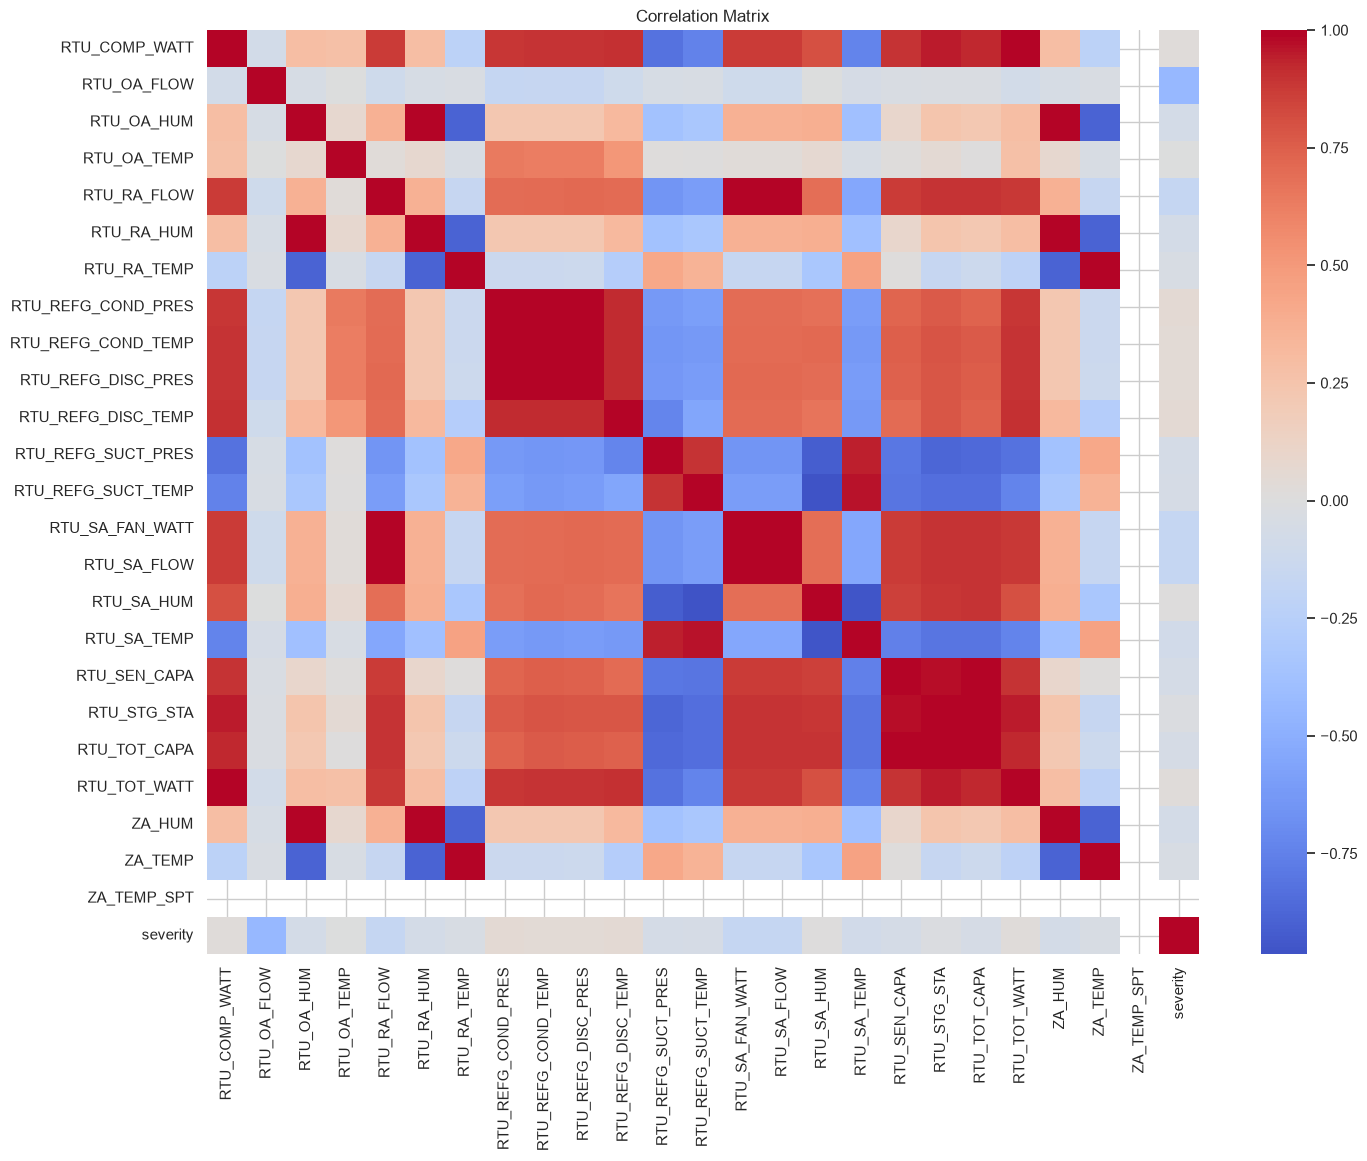

In [25]:
numeric = processed_simulation.select_dtypes(include="number")

plt.figure(figsize=(16,12))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

## 10. Important HVAC Feature Analysis

A small set of representative HVAC measurements is examined in greater detail rather than visualizing every available sensor.


In [26]:
important_features = [
    "RTU_COMP_WATT",
    "RTU_SA_TEMP",
    "RTU_RA_TEMP",
    "RTU_OA_TEMP",
    "RTU_REFG_COND_PRES",
    "RTU_REFG_DISC_PRES",
    "RTU_REFG_SUCT_PRES",
    "ZA_TEMP"
]

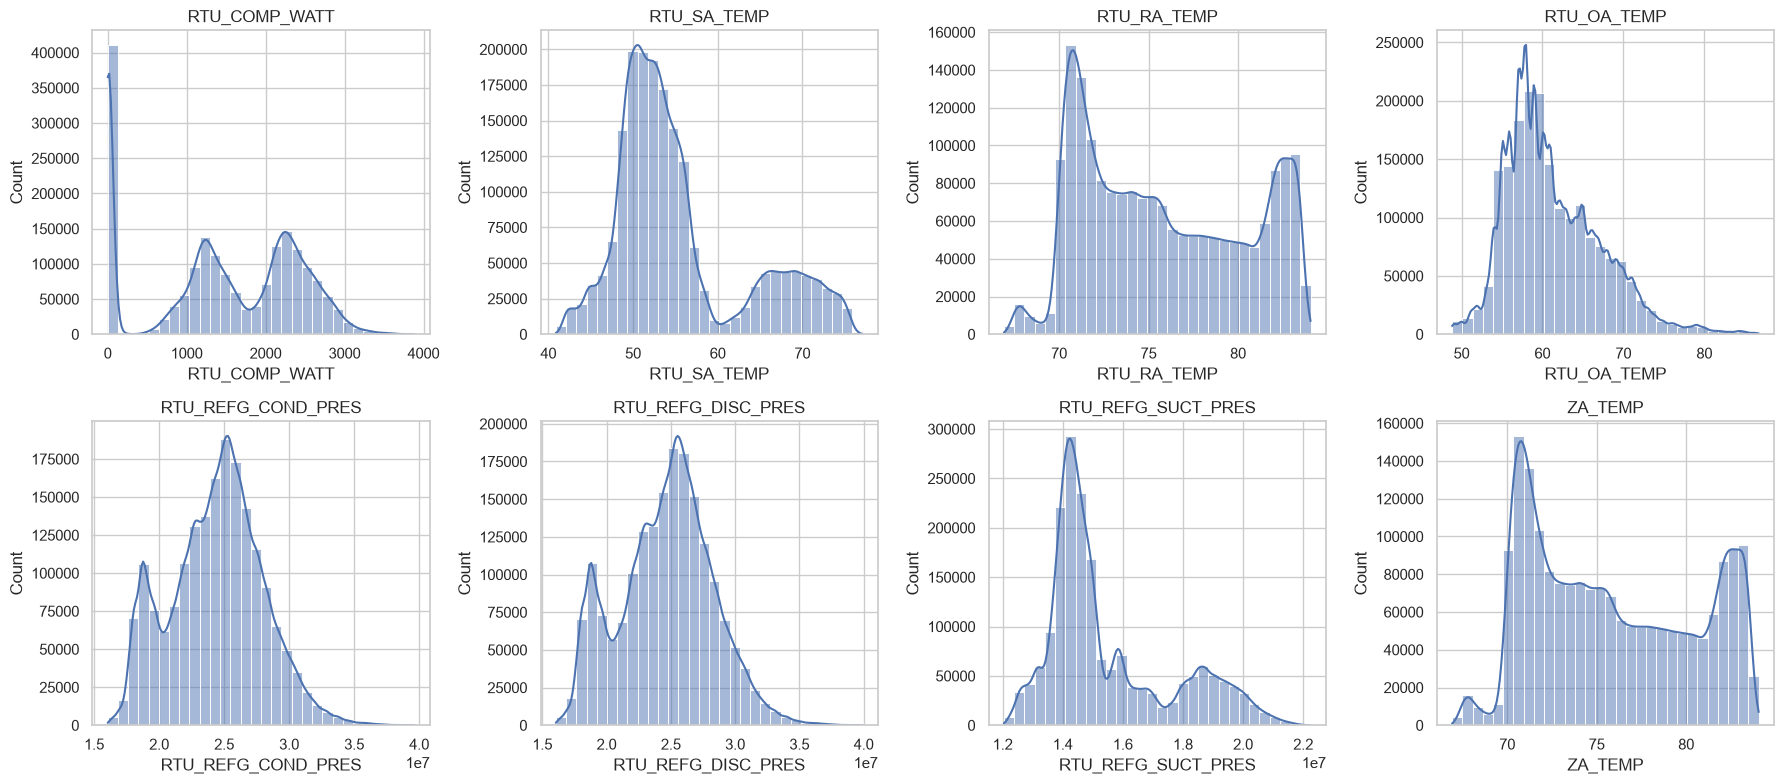

In [27]:
fig, axes = plt.subplots(2,4, figsize=(18,8))

axes = axes.flatten()

for i, feature in enumerate(important_features):

    sns.histplot(
        processed_simulation[feature],
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

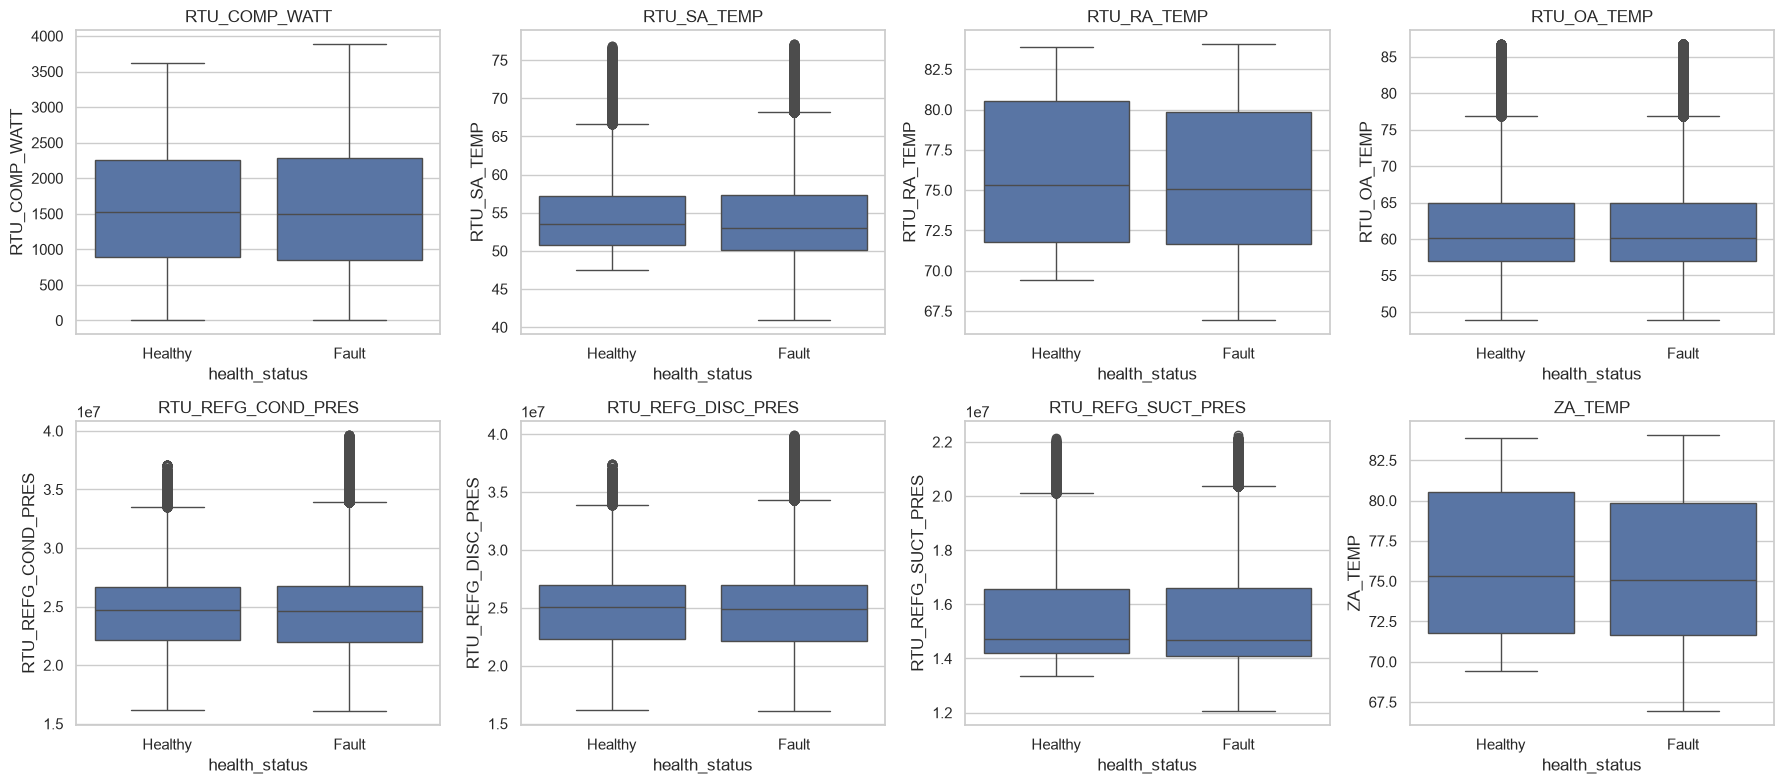

In [28]:
fig, axes = plt.subplots(2,4, figsize=(18,8))

axes = axes.flatten()

for i, feature in enumerate(important_features):

    sns.boxplot(
        data=processed_simulation,
        x="health_status",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)

plt.tight_layout()

plt.show()

## 11. Relationship Between Sensor Features and Fault Status

To understand which numerical HVAC measurements are most associated with fault conditions, a temporary binary target is created from the existing `health_status` label.

- `0` represents Healthy operation
- `1` represents Fault operation

The correlation with this temporary target is used only for exploratory analysis and does not modify the dataset used by the machine learning pipeline.

In [29]:
processed_simulation["target"] = (
    processed_simulation["health_status"] == "Fault"
).astype(int)

corr = (
    processed_simulation
    .select_dtypes(include="number")
    .corr()["target"]
    .sort_values(ascending=False)
)

display(corr)

target                1.000000e+00
severity              5.741049e-01
RTU_SA_HUM            4.966381e-03
RTU_REFG_DISC_TEMP    2.860354e-03
RTU_OA_TEMP          -1.167761e-08
RTU_REFG_COND_PRES   -2.377959e-03
RTU_COMP_WATT        -2.389083e-03
RTU_REFG_DISC_PRES   -3.176268e-03
RTU_REFG_COND_TEMP   -3.289646e-03
RTU_TOT_WATT         -3.545842e-03
RTU_RA_HUM           -8.315584e-03
ZA_HUM               -8.317175e-03
RTU_OA_HUM           -8.320797e-03
RTU_STG_STA          -9.570557e-03
RTU_REFG_SUCT_TEMP   -1.687532e-02
RTU_REFG_SUCT_PRES   -1.954145e-02
ZA_TEMP              -1.963477e-02
RTU_RA_TEMP          -1.963520e-02
RTU_TOT_CAPA         -2.081005e-02
RTU_SEN_CAPA         -2.634668e-02
RTU_SA_TEMP          -2.770715e-02
RTU_SA_FLOW          -6.039950e-02
RTU_RA_FLOW          -6.039950e-02
RTU_SA_FAN_WATT      -6.039950e-02
RTU_OA_FLOW          -1.433456e-01
ZA_TEMP_SPT                    NaN
Name: target, dtype: float64

## 12. Constant and Near-Constant Features

Features with little or no variation may provide limited information for machine learning models.

This analysis identifies:

- Constant features with only one unique value
- Features with very few unique values

No features are removed at this stage. The results are used as an exploratory reference for the subsequent feature engineering stage.

In [31]:
# Constant features
constant_features = [
    col for col in processed_simulation.columns
    if processed_simulation[col].nunique() == 1
]

print("Constant Features:")
print(constant_features)

# Near-constant features
near_constant = processed_simulation.nunique().sort_values()

display(near_constant.head(10))

Constant Features:
['ZA_TEMP_SPT']


ZA_TEMP_SPT          1
health_status        2
target               2
RTU_OA_FLOW          4
fault_type           5
severity             5
RTU_STG_STA        233
RTU_RA_FLOW        874
RTU_SA_FLOW        874
RTU_SA_FAN_WATT    887
dtype: int64

# 13. EDA Summary

The exploratory analysis provided an overview of the processed HVAC simulation dataset.

Key observations include:

- The dataset contains both healthy and faulty HVAC operating conditions.
- Fault-related class distribution was examined to understand the dataset composition.
- Representative HVAC variables such as compressor power, supply air temperature, and condenser pressure were analyzed against system health.
- Correlation analysis was used to identify relationships between numerical sensor measurements and fault status.
- Constant and near-constant features were identified for consideration during feature engineering.

The findings from this analysis provide the basis for the next stage: feature engineering and preparation of the data for machine learning.